Import modules

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Load dataset penncath_preprocessing.csv

In [85]:
dataset = pd.read_csv('../data/penncath_preprocessed.csv')
snp_cols = [col for col in dataset.columns if col != 'target']

X = dataset[snp_cols]
Y = dataset['target']

1. Basic dataset info

In [86]:
print("Samples:", dataset.shape[0])
print("SNP features:", len(snp_cols))
print("Class distribution:", Y.value_counts().to_dict())

print("\nStatistical summary (first 5 SNPs):")
print(X.iloc[:, :5].describe().round(3))

Samples: 926
SNP features: 100
Class distribution: {0: 463, 1: 463}

Statistical summary (first 5 SNPs):
       rs369427_C  rs16831558_A  rs7515895_G  rs832179_C  rs17005517_A
count     926.000       926.000      926.000     926.000       926.000
mean        0.921         0.299        0.388       0.671         0.546
std         0.692         0.526        0.552       0.665         0.646
min         0.000         0.000        0.000       0.000         0.000
25%         0.000         0.000        0.000       0.000         0.000
50%         1.000         0.000        0.000       1.000         0.000
75%         1.000         1.000        1.000       1.000         1.000
max         2.000         2.000        2.000       2.000         2.000


2. Genotype distributions (first 6 SNPs)

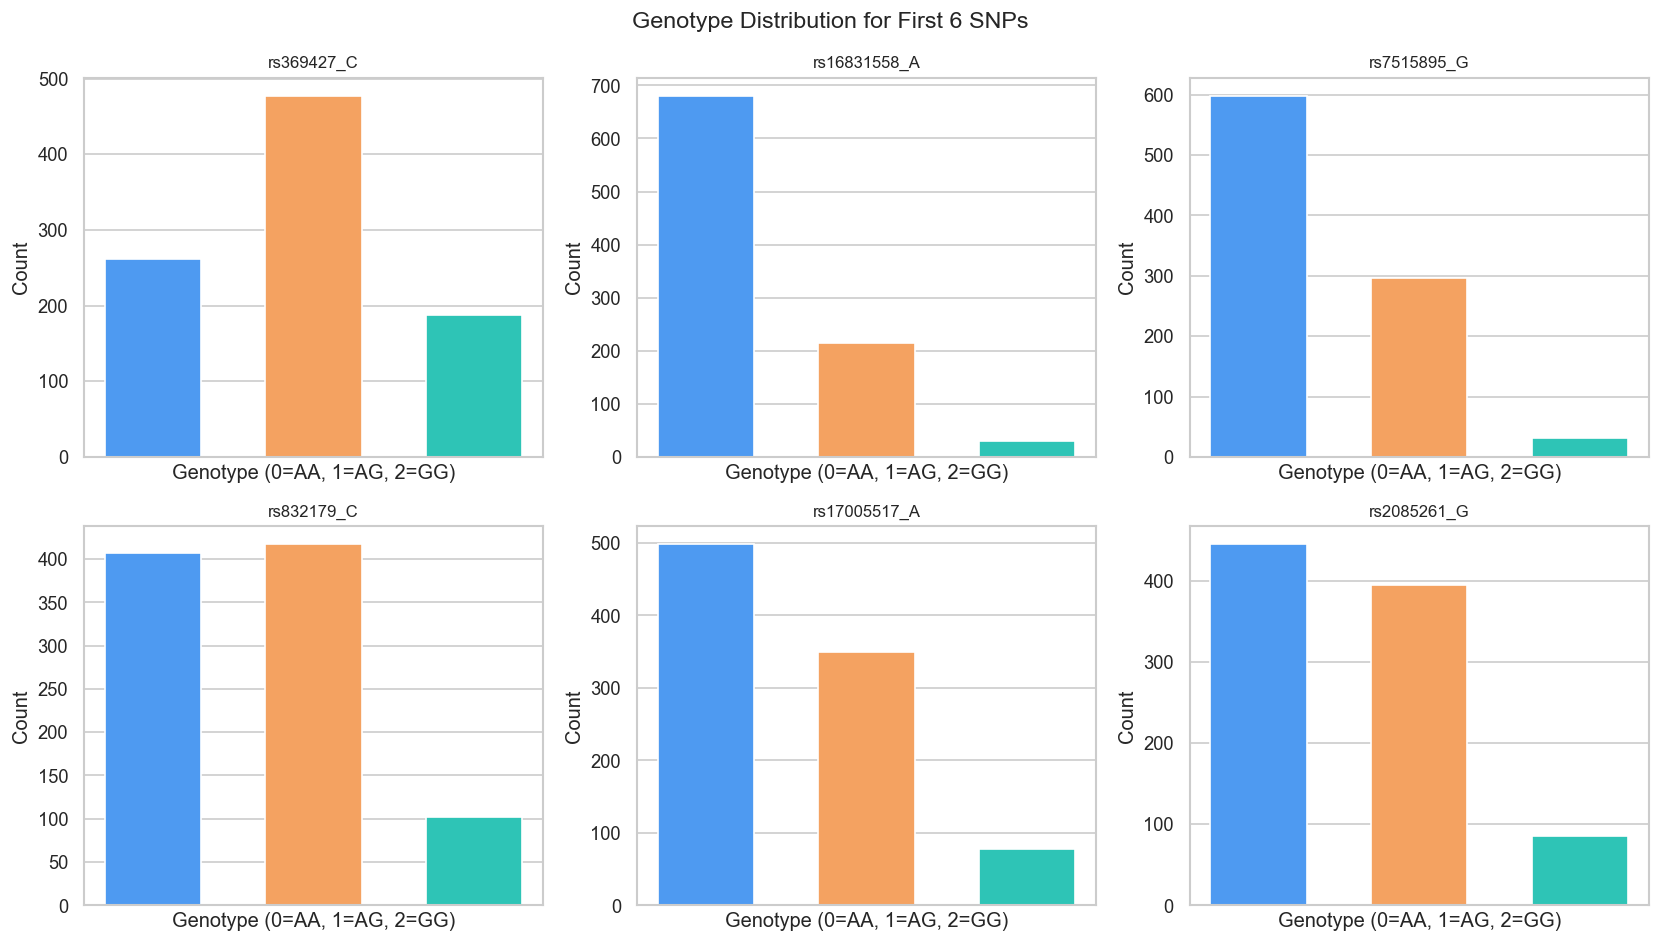

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Genotype Distribution for First 6 SNPs', fontsize=14)

for i, col in enumerate(snp_cols[:6]):
    ax = axes[i // 3][i % 3]
    vals = X[col].value_counts().sort_index()
    ax.bar(vals.index, vals.values, color=['#4e9af1','#f4a261','#2ec4b6'], width=0.6)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Genotype (0=AA, 1=AG, 2=GG)')
    ax.set_ylabel('Count')
    ax.set_xticks([])

plt.tight_layout()
plt.savefig('../plots/eda_genotype_distribution.png', bbox_inches='tight')

3. Class distribution

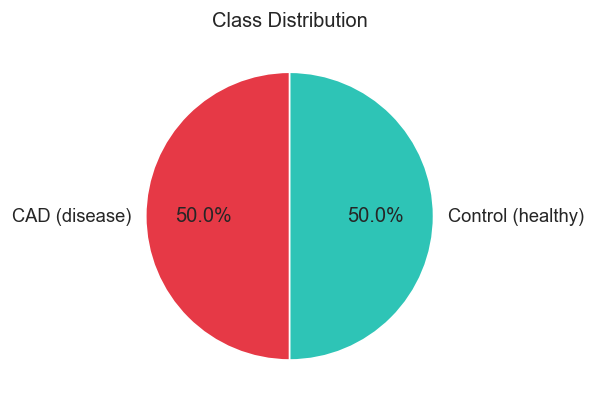

In [88]:
plt.figure(figsize=(5, 5))
Y.value_counts().plot.pie(
    labels=['CAD (disease)', 'Control (healthy)'],
    colors=["#e63946", "#2ec4b6"],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Class Distribution')
plt.tight_layout()
plt.savefig('../plots/eda_class_distribution.png', bbox_inches='tight')

4. Correlation with target


Top 10 SNPs correlated with CAD:
rs10241452_T    0.1504
rs10182136_C    0.1456
rs2085261_G     0.1444
rs648166_T      0.1431
rs2841390_C     0.1429
rs10197090_C    0.1416
rs6744132_A     0.1410
rs9345833_T     0.1397
rs2207121_T     0.1393
rs3887998_T     0.1382
rs17818373_A    0.1381
rs9294702_A     0.1371
rs4684284_A     0.1366
rs1508966_C     0.1366
rs17042365_T    0.1362
dtype: float64


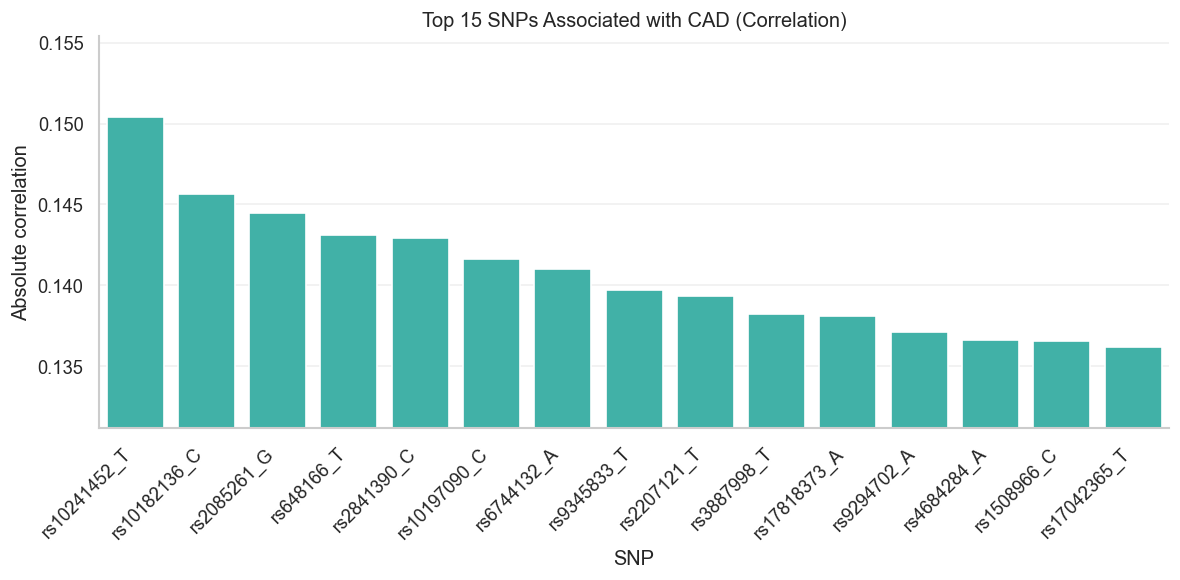

In [89]:
correlations = X.corrwith(Y).abs().sort_values(ascending=False)

print("\nTop 10 SNPs correlated with CAD:")
print(correlations.head(15).round(4))

top15 = correlations.head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top15.index, y=top15.values, color="#2ec4b6")
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 SNPs Associated with CAD (Correlation)', fontsize=12)
plt.xlabel('SNP')
plt.ylabel('Absolute correlation')
plt.ylim(top15.min() - 0.005, top15.max() + 0.005)
plt.grid(axis='y', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('../plots/eda_top_correlations.png', bbox_inches='tight')

5. Heatmap (top 20 SNPs)

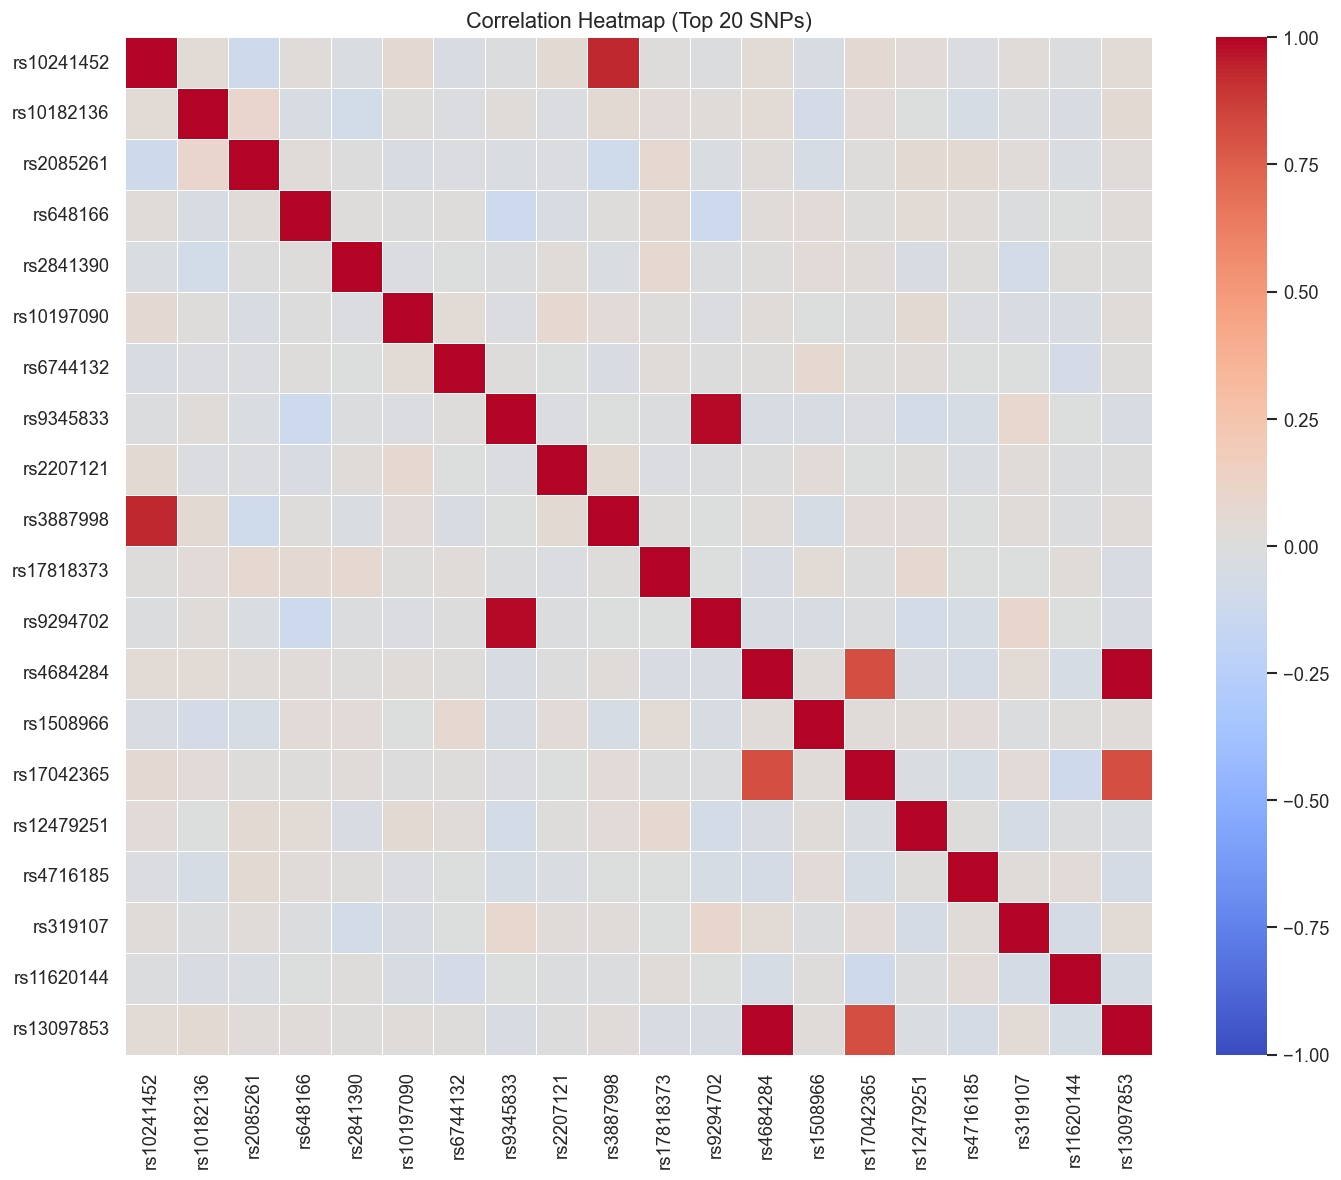

In [90]:
top20 = correlations.head(20).index.tolist()
corr_matrix = dataset[top20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    xticklabels=[c.split('_')[0] for c in top20],
    yticklabels=[c.split('_')[0] for c in top20]
)
plt.title('Correlation Heatmap (Top 20 SNPs)', fontsize=13)
plt.tight_layout()
plt.savefig('../plots/eda_heatmap.png', bbox_inches='tight')

6. Genotype vs class (top 6 SNPs)

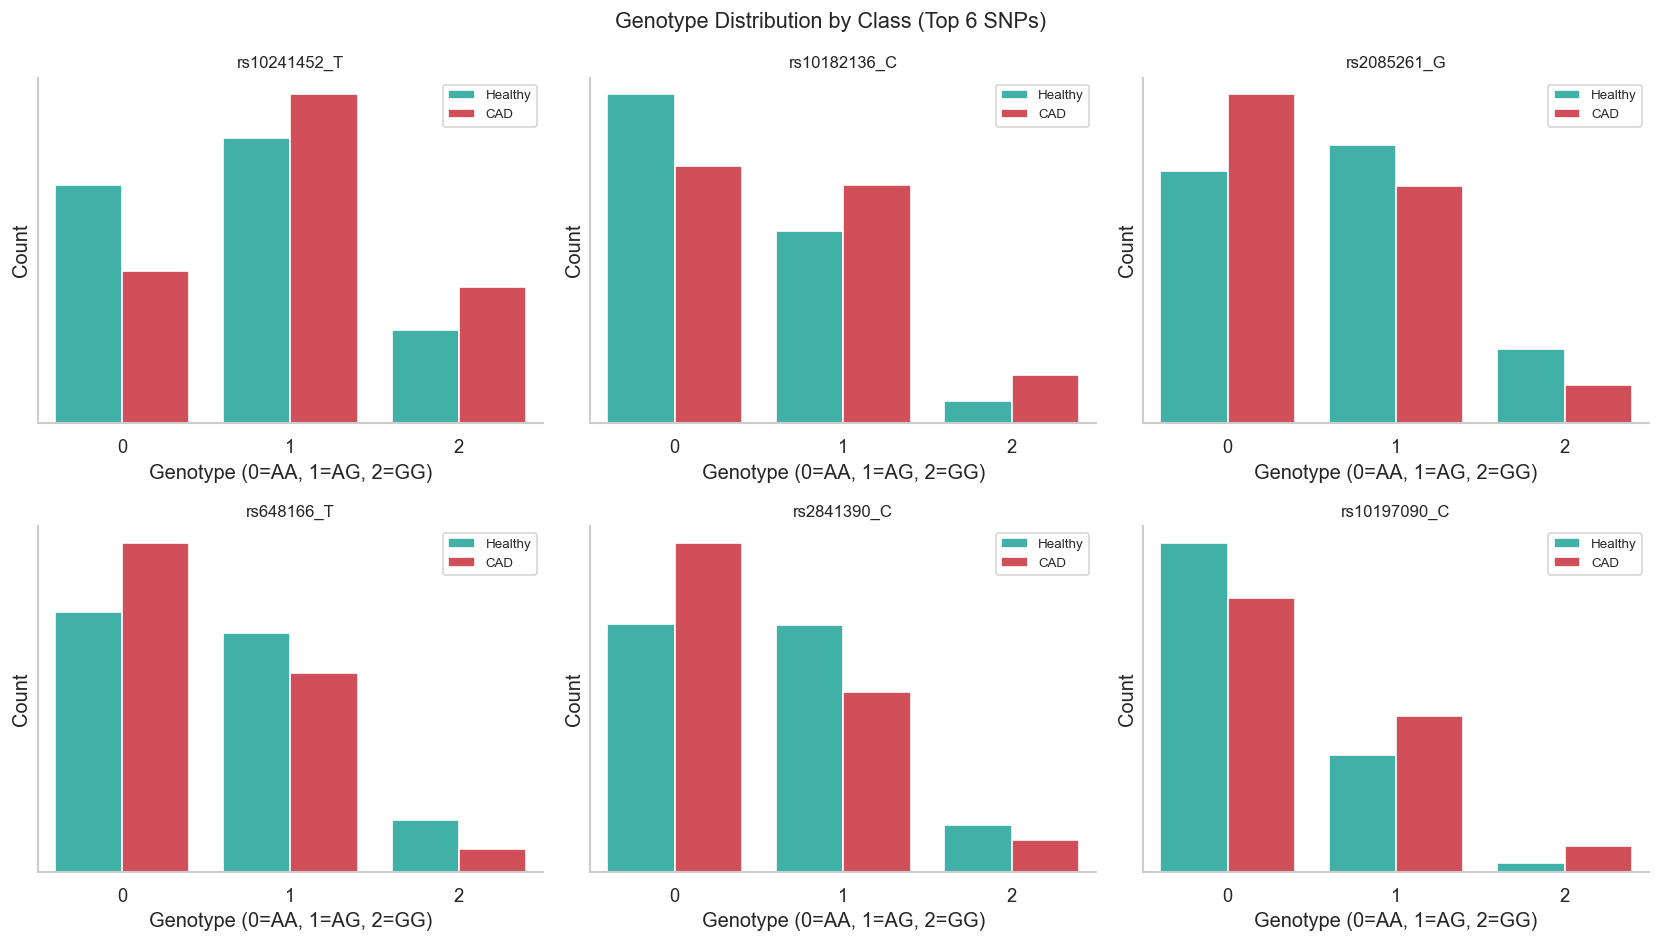

In [91]:
top6 = correlations.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Genotype Distribution by Class (Top 6 SNPs)', fontsize=13)

for i, col in enumerate(top6):
    ax = axes[i // 3][i % 3]
    sns.countplot(
        x=col,
        hue='target',
        data=dataset,
        palette=["#2ec4b6", "#e63946"],
        ax=ax
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Genotype (0=AA, 1=AG, 2=GG)')
    ax.set_ylabel('Count')
    ax.legend(['Healthy', 'CAD'], fontsize=8)
    ax.set_yticks([])

sns.despine()
plt.tight_layout()
plt.savefig('../plots/eda_genotype_by_class.png', bbox_inches='tight')

7. PCA analysis


Explained variance by components:
PC1: 6.26%
PC2: 5.97%
PC3: 4.95%
PC4: 4.64%
PC5: 4.14%
PC6: 3.78%
PC7: 3.56%
PC8: 3.13%
PC9: 2.94%
PC10: 2.86%
Total (PC1 + PC2): 12.23%


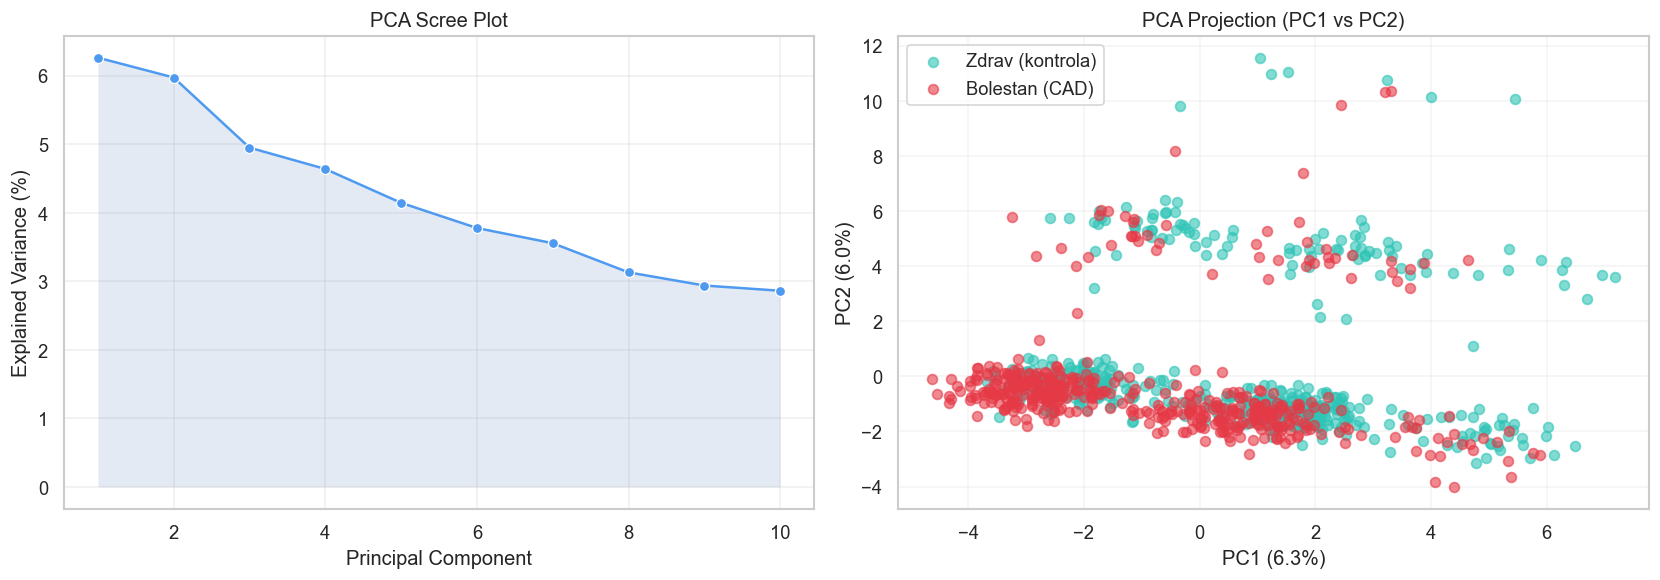

In [92]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

print("\nExplained variance by components:")
for i, var in enumerate(explained):
    print(f"PC{i+1}: {var:.2f}%")

print(f"Total (PC1 + PC2): {explained[:2].sum():.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=range(1, 11), y=explained, marker='o', ax=ax1, color="#4e9af1")
ax1.fill_between(range(1, 11), explained, alpha=0.15)
ax1.set_title('PCA Scree Plot')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.grid(True, alpha=0.3)

colors = {0: '#2ec4b6', 1: '#e63946'}
labels = {0: 'Zdrav (kontrola)', 1: 'Bolestan (CAD)'}
for cls in [0, 1]:
    mask = Y == cls
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cls], label=labels[cls], alpha=0.6, s=35)

ax2.set_xlabel(f'PC1 ({explained[0]:.1f}%)')
ax2.set_ylabel(f'PC2 ({explained[1]:.1f}%)')
ax2.set_title('PCA Projection (PC1 vs PC2)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../plots/eda_pca.png', bbox_inches='tight')